# Ma'al Project — Founder Model Training

## Team Members
- Abdulaziz Alsharif
- Anas Al-Zahrani
- Mohammed
- Majid

## Problem Description
This notebook builds a regression model to predict the survival_score for startups.
The goal is to help founders understand their startup strength and survival potential based on funding, company age, sector, city, investors, and support program participation.
The notebook compares a Linear Regression baseline model with a Random Forest Regressor and selects the best-performing model as the final choice.

In [164]:
# ==============================
# Founder Dataset - Preprocessing + Visualization
# Ma'al Project
# Target: survival_score | Task: Regression
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import io

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [165]:
# ==============================
# 1) Load Dataset
# ==============================

founder_path = "founder_dataset.csv"
df = pd.read_csv(founder_path)

print("Founder Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Founder Dataset Shape: (10000, 15)

Columns:
['sector', 'city', 'founded_year', 'startup_age_years', 'funding_stage', 'total_funding_sar', 'num_funding_rounds', 'num_investors', 'num_founders', 'speed_to_first_round_months', 'last_round_type', 'sama_sandbox', 'rega_sandbox', 'ntdp_participation', 'survival_score']


In [166]:
# ==============================
# 2) Expected Columns Check
# ==============================

expected_columns = [
    "sector",
    "city",
    "founded_year",
    "startup_age_years",
    "funding_stage",
    "total_funding_sar",
    "num_funding_rounds",
    "num_investors",
    "num_founders",
    "speed_to_first_round_months",
    "last_round_type",
    "sama_sandbox",
    "rega_sandbox",
    "ntdp_participation",
    "survival_score"
]

actual_columns = df.columns.tolist()

missing_columns = [col for col in expected_columns if col not in actual_columns]
extra_columns = [col for col in actual_columns if col not in expected_columns]

print("\n==============================")
print("Founder Feature Check")
print("==============================")

if len(missing_columns) == 0 and len(extra_columns) == 0:
    print("✅ الأعمدة مطابقة للمتطلبات")
else:
    print("❌ فيه اختلاف في الأعمدة")

print("Missing Columns:", missing_columns)
print("Extra Columns:", extra_columns)


Founder Feature Check
✅ الأعمدة مطابقة للمتطلبات
Missing Columns: []
Extra Columns: []


In [167]:
# ==============================
# 3) Basic Data Quality Check
# ==============================

print("\n==============================")
print("Data Quality Report")
print("==============================")

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicated Rows:")
print(df.duplicated().sum())

print("\nNumerical Summary:")
print(df.describe())


Data Quality Report

Data Types:
sector                          object
city                            object
founded_year                     int64
startup_age_years                int64
funding_stage                   object
total_funding_sar                int64
num_funding_rounds               int64
num_investors                    int64
num_founders                     int64
speed_to_first_round_months      int64
last_round_type                 object
sama_sandbox                     int64
rega_sandbox                     int64
ntdp_participation               int64
survival_score                 float64
dtype: object

Missing Values:
sector                         0
city                           0
founded_year                   0
startup_age_years              0
funding_stage                  0
total_funding_sar              0
num_funding_rounds             0
num_investors                  0
num_founders                   0
speed_to_first_round_months    0
last_round_type     

In [168]:
# ==============================
# 4) Binary Columns Check
# ==============================

binary_columns = [
    "sama_sandbox",
    "rega_sandbox",
    "ntdp_participation"
]

print("\n==============================")
print("Binary Columns Check")
print("==============================")

for col in binary_columns:
    values = sorted(df[col].dropna().unique())
    if set(values).issubset({0, 1}):
        print(f"✅ {col} صحيح: {values}")
    else:
        print(f"❌ {col} فيه قيم غير صحيحة: {values}")


Binary Columns Check
✅ sama_sandbox صحيح: [np.int64(0), np.int64(1)]
✅ rega_sandbox صحيح: [np.int64(0), np.int64(1)]
✅ ntdp_participation صحيح: [np.int64(0), np.int64(1)]


In [169]:
# ==============================
# 5) Target Range Check
# ==============================

target = "survival_score"

invalid_target = df[(df[target] < 0) | (df[target] > 100)]

print("\n==============================")
print("Target Range Check")
print("==============================")

if invalid_target.empty:
    print("✅ survival_score داخل النطاق الصحيح من 0 إلى 100")
else:
    print("❌ survival_score فيه قيم خارج النطاق")
    print(invalid_target[[target]].head())


Target Range Check
✅ survival_score داخل النطاق الصحيح من 0 إلى 100


In [170]:

# ==============================
# 6) Redundancy Check (NEW)
#    - last_round_type vs funding_stage
#    - startup_age_years vs founded_year
# ==============================

print("\n==============================")
print("Redundancy Check")
print("==============================")

same_round = (df["last_round_type"] == df["funding_stage"]).all()
print(f"last_round_type == funding_stage : {same_round}  -> سيتم حذف last_round_type" if same_round
      else "last_round_type يختلف عن funding_stage -> نبقيه")

ref_year = int((df["founded_year"] + df["startup_age_years"]).mode()[0])
same_age = (df["startup_age_years"] == (ref_year - df["founded_year"])).all()
print(f"startup_age_years = {ref_year} - founded_year : {same_age}  -> سيتم حذف founded_year"
      if same_age else "العمر لا يطابق سنة التأسيس -> نبقي العمودين")


Redundancy Check
last_round_type == funding_stage : True  -> سيتم حذف last_round_type
startup_age_years = 2024 - founded_year : True  -> سيتم حذف founded_year


In [171]:
# ==============================
# 7) Cleaning
# ==============================

df_clean = df.copy()

# Remove duplicated rows
df_clean = df_clean.drop_duplicates()

# Clean text columns
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Fill missing values
numerical_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

for col in numerical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("\nCleaned Founder Dataset Shape:", df_clean.shape)


Cleaned Founder Dataset Shape: (10000, 15)


In [172]:
# ==============================
# 8) Outlier Detection + Handling - IQR (FIXED)
#    Cap outliers instead of only printing them.
#    Target column is excluded from capping.
# ==============================

print("\n==============================")
print("Outlier Report (before capping)")
print("==============================")

cols_to_cap = [c for c in numerical_cols if c != target]

for col in cols_to_cap:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

    # Cap (winsorize) the outliers to the IQR bounds
    df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

print("\n✅ Outliers capped to IQR bounds")


Outlier Report (before capping)
founded_year: 0 outliers
startup_age_years: 0 outliers
total_funding_sar: 1641 outliers
num_funding_rounds: 108 outliers
num_investors: 945 outliers
num_founders: 0 outliers
speed_to_first_round_months: 55 outliers
sama_sandbox: 1146 outliers
rega_sandbox: 1091 outliers
ntdp_participation: 0 outliers

✅ Outliers capped to IQR bounds


In [173]:

# ==============================
# 9) Drop Redundant Columns (NEW)
#    - last_round_type (duplicate of funding_stage)
#    - founded_year (duplicate info of startup_age_years)
# ==============================

drop_cols = []
if (df_clean["last_round_type"] == df_clean["funding_stage"]).all():
    drop_cols.append("last_round_type")
if (df_clean["startup_age_years"] == (ref_year - df_clean["founded_year"])).all():
    drop_cols.append("founded_year")

df_clean = df_clean.drop(columns=drop_cols)
print("\nDropped redundant columns:", drop_cols)
print("Founder Dataset Shape after drop:", df_clean.shape)



Dropped redundant columns: ['last_round_type', 'founded_year']
Founder Dataset Shape after drop: (10000, 13)


In [174]:
# ==============================
# FEATURE ENGINEERING
# ==============================

df_clean["funding_per_round"] = df_clean["total_funding_sar"] / df_clean["num_funding_rounds"].replace(0, np.nan)
df_clean["funding_per_round"] = df_clean["funding_per_round"].fillna(0)

df_clean["investment_per_founder"] = df_clean["total_funding_sar"] / df_clean["num_founders"].replace(0, np.nan)
df_clean["investment_per_founder"] = df_clean["investment_per_founder"].fillna(0)

df_clean["regulatory_support"] = df_clean["sama_sandbox"] + df_clean["rega_sandbox"] + df_clean["ntdp_participation"]

print("✅ Feature engineering done")
print(df_clean[["funding_per_round", "investment_per_founder", "regulatory_support"]].describe())


✅ Feature engineering done
       funding_per_round  investment_per_founder  regulatory_support
count       10000.000000            10000.000000        10000.000000
mean         2688.037582             4894.898768            0.348300
std          2829.493513             7203.023117            0.476455
min            50.000000               25.250000            0.000000
25%           386.000000              289.666667            0.000000
50%          1430.375000             1289.500000            0.000000
75%          4754.916667             6916.750000            1.000000
max         11173.625000            33520.875000            1.000000


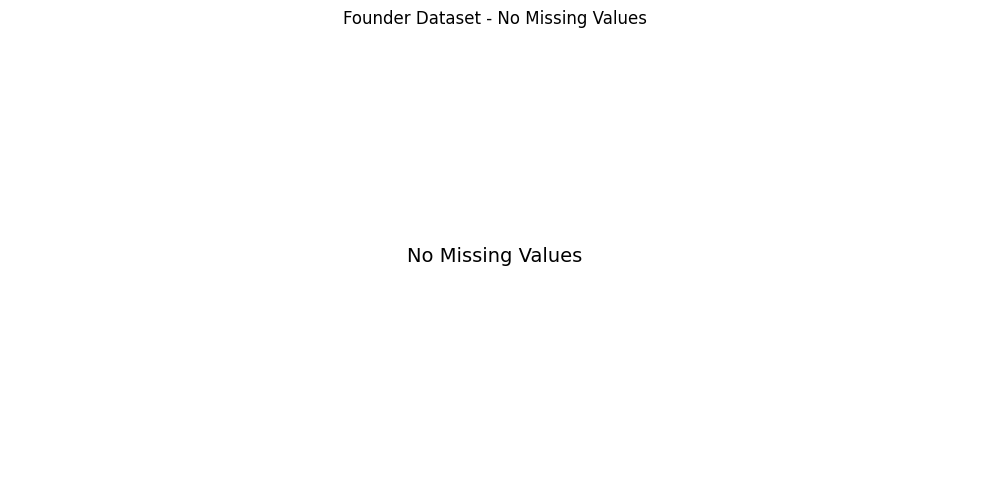

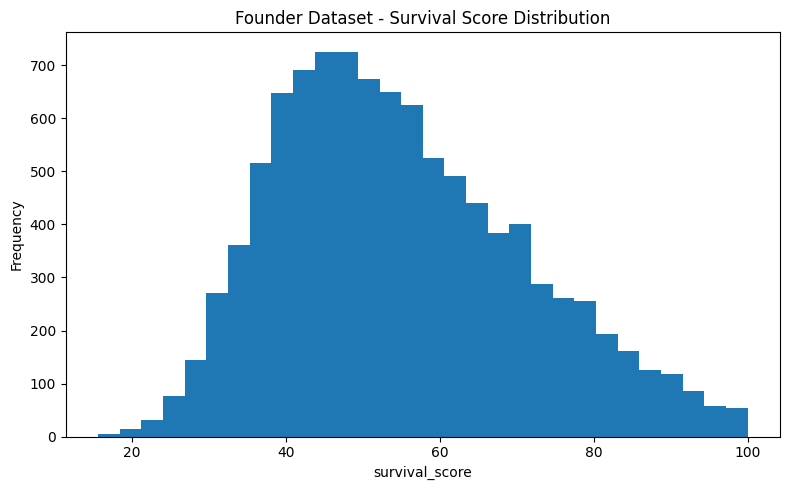

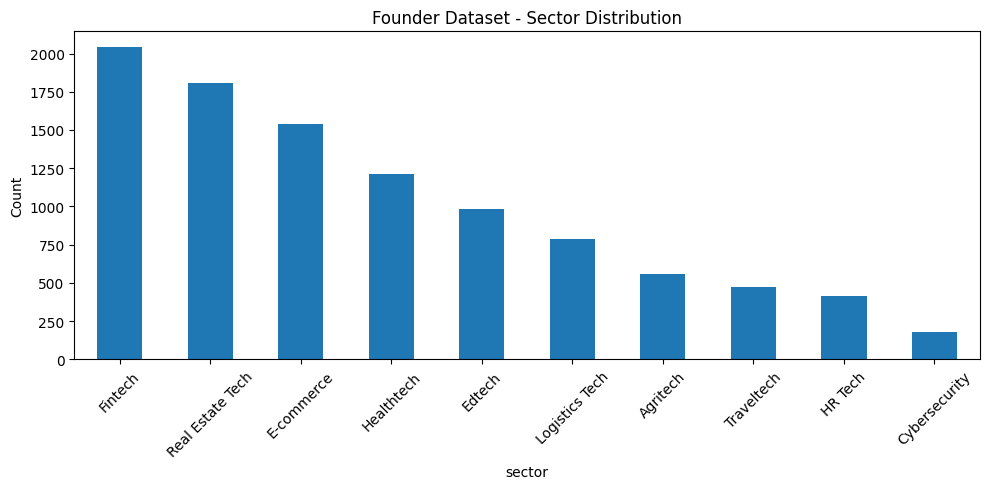

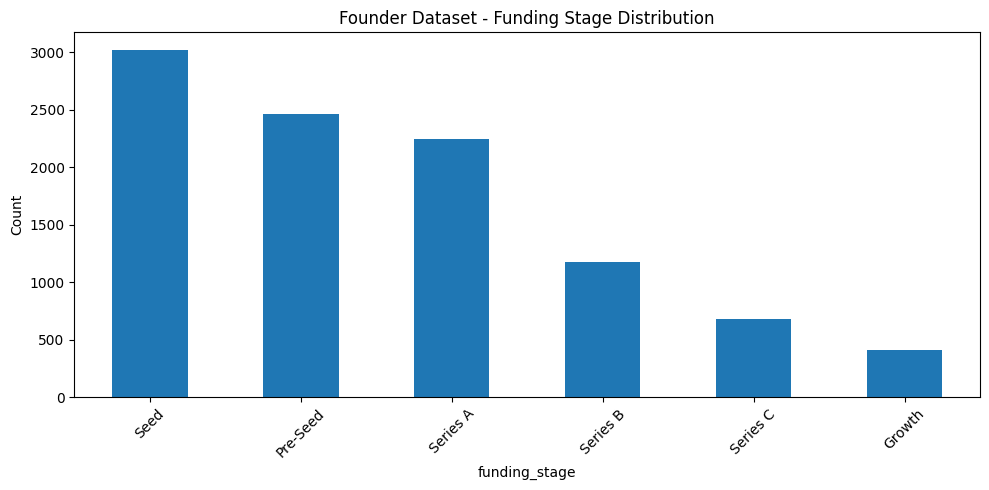

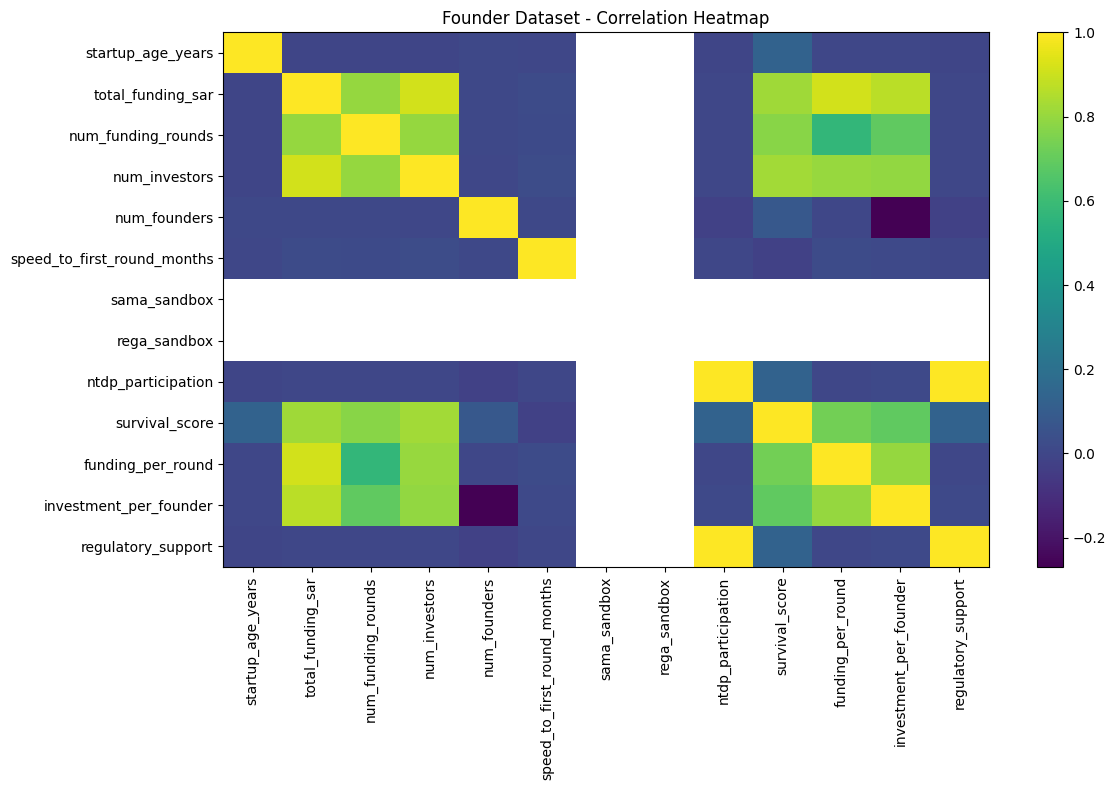

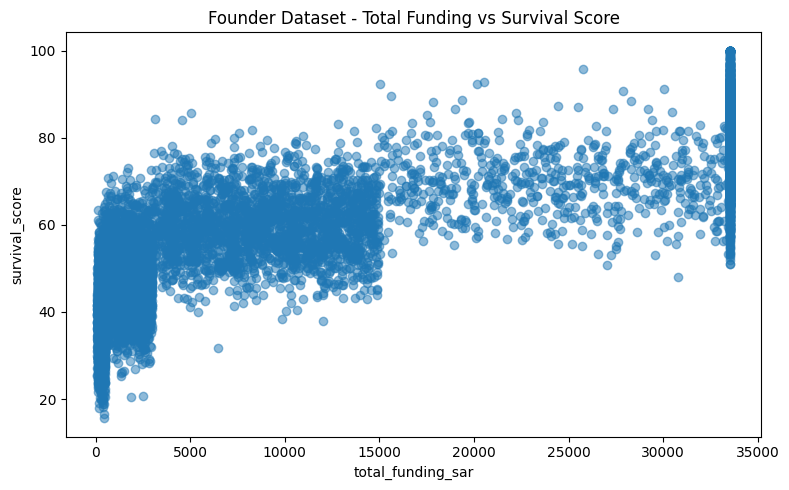

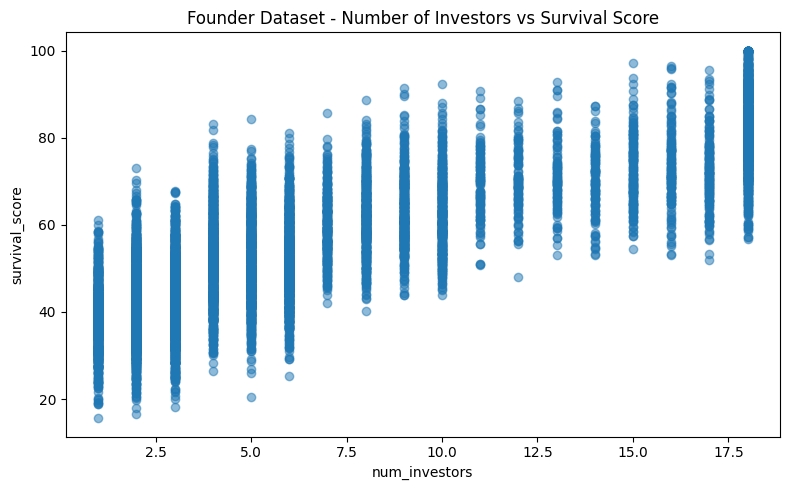

In [175]:
# ==============================
# 10) Visualization
# ==============================

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(10, 5))
if len(missing) == 0:
    plt.title("Founder Dataset - No Missing Values")
    plt.text(0.5, 0.5, "No Missing Values", ha="center", va="center", fontsize=14)
    plt.axis("off")
else:
    missing.plot(kind="bar")
    plt.title("Founder Dataset - Missing Values")
    plt.xlabel("Columns")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Target distribution
plt.figure(figsize=(8, 5))
plt.hist(df_clean["survival_score"], bins=30)
plt.title("Founder Dataset - Survival Score Distribution")
plt.xlabel("survival_score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Sector distribution
plt.figure(figsize=(10, 5))
df_clean["sector"].value_counts().plot(kind="bar")
plt.title("Founder Dataset - Sector Distribution")
plt.xlabel("sector")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Funding stage distribution
plt.figure(figsize=(10, 5))
df_clean["funding_stage"].value_counts().plot(kind="bar")
plt.title("Founder Dataset - Funding Stage Distribution")
plt.xlabel("funding_stage")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation heatmap
numeric_df = df_clean.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Founder Dataset - Correlation Heatmap")
plt.tight_layout()
plt.show()

# Scatter: total funding vs survival score
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["total_funding_sar"], df_clean["survival_score"], alpha=0.5)
plt.title("Founder Dataset - Total Funding vs Survival Score")
plt.xlabel("total_funding_sar")
plt.ylabel("survival_score")
plt.tight_layout()
plt.show()

# Scatter: investors vs survival score
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["num_investors"], df_clean["survival_score"], alpha=0.5)
plt.title("Founder Dataset - Number of Investors vs Survival Score")
plt.xlabel("num_investors")
plt.ylabel("survival_score")
plt.tight_layout()
plt.show()


In [176]:
# ==============================
# 11) Prepare X and y
# ==============================

X = df_clean.drop(columns=["survival_score"])
y = df_clean["survival_score"]

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)
print("Feature columns:", X.columns.tolist())


X Shape: (10000, 15)
y Shape: (10000,)
Feature columns: ['sector', 'city', 'startup_age_years', 'funding_stage', 'total_funding_sar', 'num_funding_rounds', 'num_investors', 'num_founders', 'speed_to_first_round_months', 'sama_sandbox', 'rega_sandbox', 'ntdp_participation', 'funding_per_round', 'investment_per_founder', 'regulatory_support']


In [177]:
# ==============================
# 12) Train Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nX_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (8000, 15)
X_test: (2000, 15)
y_train: (8000,)
y_test: (2000,)


In [178]:
# ==============================
# 13) Preprocessing Pipeline
#     Note: No StandardScaler for Random Forest (tree-based, scale-invariant).
#     If you later compare with Logistic Regression / SVM, add scaling there.
# ==============================

categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\n==============================")
print("Founder Preprocessing Done")
print("==============================")
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)
print("Processed X_train Shape:", X_train_processed.shape)
print("Processed X_test Shape:", X_test_processed.shape)

print("\n✅ Founder Dataset جاهز للتدريب")
print("Target: survival_score")
print("Task Type: Regression")


Founder Preprocessing Done
Numerical Features: ['startup_age_years', 'total_funding_sar', 'num_funding_rounds', 'num_investors', 'num_founders', 'speed_to_first_round_months', 'sama_sandbox', 'rega_sandbox', 'ntdp_participation', 'funding_per_round', 'investment_per_founder', 'regulatory_support']
Categorical Features: ['sector', 'city', 'funding_stage']
Processed X_train Shape: (8000, 36)
Processed X_test Shape: (2000, 36)

✅ Founder Dataset جاهز للتدريب
Target: survival_score
Task Type: Regression


In [179]:
# learning curve function
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=5,
        scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8,5))

    plt.plot(train_sizes, train_mean, marker="o", label="Training Score")
    plt.plot(train_sizes, val_mean, marker="o", label="Validation Score")

    plt.fill_between(
        train_sizes,
        train_mean-train_std,
        train_mean+train_std,
        alpha=0.2
    )

    plt.fill_between(
        train_sizes,
        val_mean-val_std,
        val_mean+val_std,
        alpha=0.2
    )

    plt.title(title)
    plt.xlabel("Training Examples")
    plt.ylabel("R² Score")
    plt.grid(True)
    plt.legend()
    plt.show()

In [180]:
# ==============================
# 14) Linear Regression Baseline Model
# ==============================

linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

linear_pred = linear_model.predict(X_test_processed)

linear_r2 = r2_score(y_test, linear_pred)
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))

cv_r2 = cross_val_score(
    linear_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="r2"
).mean()

print("\n==============================")
print("Linear Regression Baseline Results")
print("==============================")
print(f"R² Score : {linear_r2:.4f}")
print(f"MAE      : {linear_mae:.2f} pts")
print(f"RMSE     : {linear_rmse:.2f} pts")
print(f"CV R²    : {cv_r2:.2f}")


Linear Regression Baseline Results
R² Score : 0.8428
MAE      : 4.98 pts
RMSE     : 6.24 pts
CV R²    : 0.85


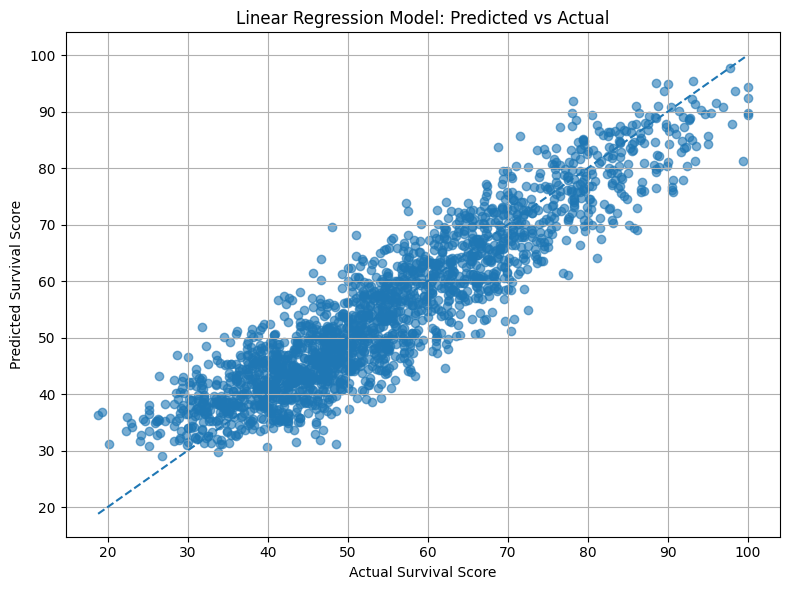

In [181]:
# ==============================
# 14) Predicted vs Actual Scatter Plot
# ==============================

plt.figure(figsize=(8, 6))
plt.scatter(y_test, linear_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Survival Score")
plt.ylabel("Predicted Survival Score")
plt.title("Linear Regression Model: Predicted vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

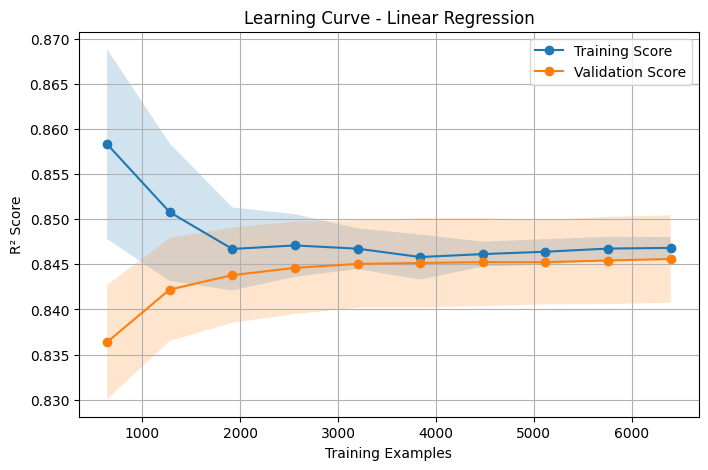

In [182]:
# Linear regression`s learning curve.

plot_learning_curve(
    linear_model,
    X_train_processed,
    y_train,
    "Learning Curve - Linear Regression"
)

In [183]:
# ======================================
# 15) Decision tree Model training and Evaluation
# ======================================
from sklearn.tree import DecisionTreeRegressor
tree_model= DecisionTreeRegressor( max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42)

tree_model.fit(X_train_processed, y_train)

tree_pred= tree_model.predict(X_test_processed)

tree_r2= r2_score(y_test, tree_pred)
tree_mae= mean_absolute_error(y_test,tree_pred)
tree_rmse= np.sqrt(mean_squared_error(y_test, tree_pred))

cv_r2 = cross_val_score(
    tree_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="r2"
).mean()

print("\n==============================")
print("Decision Tree Results")
print("==============================")
print(f"R² Score : {tree_r2:.4f}")
print(f"MAE      : {tree_mae:.2f} pts")
print(f"RMSE     : {tree_rmse:.2f} pts")
print(f"CV R²    : {cv_r2:.2f}")




Decision Tree Results
R² Score : 0.8178
MAE      : 5.34 pts
RMSE     : 6.72 pts
CV R²    : 0.82


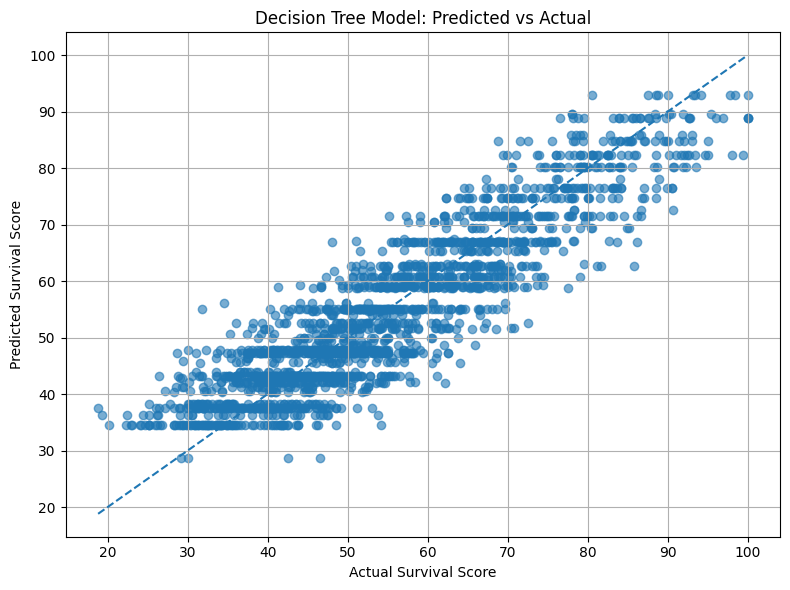

In [184]:
# ==============================================
# Decision Tree Predicted vs Actual Scatter Plot
# ==============================================

plt.figure(figsize=(8, 6))
plt.scatter(y_test, tree_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Survival Score")
plt.ylabel("Predicted Survival Score")
plt.title("Decision Tree Model: Predicted vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

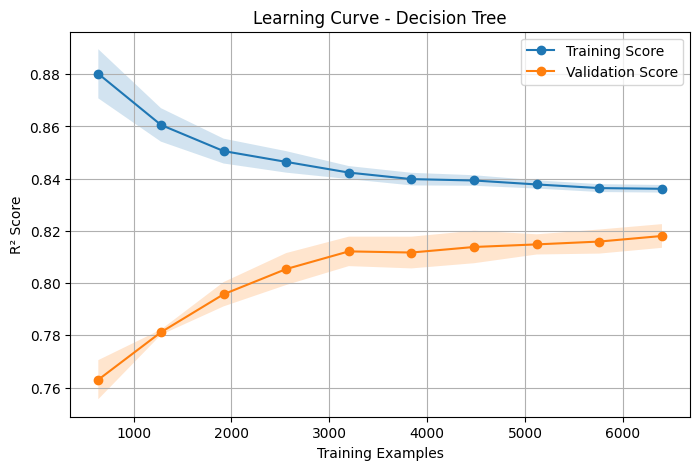

In [185]:
# Decision tree learning curve.

plot_learning_curve(
    tree_model,
    X_train_processed,
    y_train,
    "Learning Curve - Decision Tree"
)

In [186]:
# ==============================
# 16) Random Forest Model
# ==============================

model = RandomForestRegressor(
    n_estimators= 500,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=4,
    random_state=42
)

model.fit(X_train_processed, y_train)

RandomForestRegressor(max_depth=5, min_samples_leaf=4, min_samples_split=5,
                      n_estimators=500, random_state=42)

In [187]:
# ==============================
# 16) Random Forest Evaluation
# ==============================

y_pred = model.predict(X_test_processed)

rf_r2 = r2_score(y_test, y_pred)
rf_mae = mean_absolute_error(y_test, y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
cv_r2 = cross_val_score(
    model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="r2"
).mean()

print("\n==============================")
print("Founder Random Forest Final Model Evaluation")
print("==============================")
print(f"R² Score : {rf_r2:.4f}")
print(f"MAE      : {rf_mae:.2f} pts")
print(f"RMSE     : {rf_rmse:.2f} pts")
print(f"CV R²    : {cv_r2:.2f}")


Founder Random Forest Final Model Evaluation
R² Score : 0.8203
MAE      : 5.31 pts
RMSE     : 6.67 pts
CV R²    : 0.82


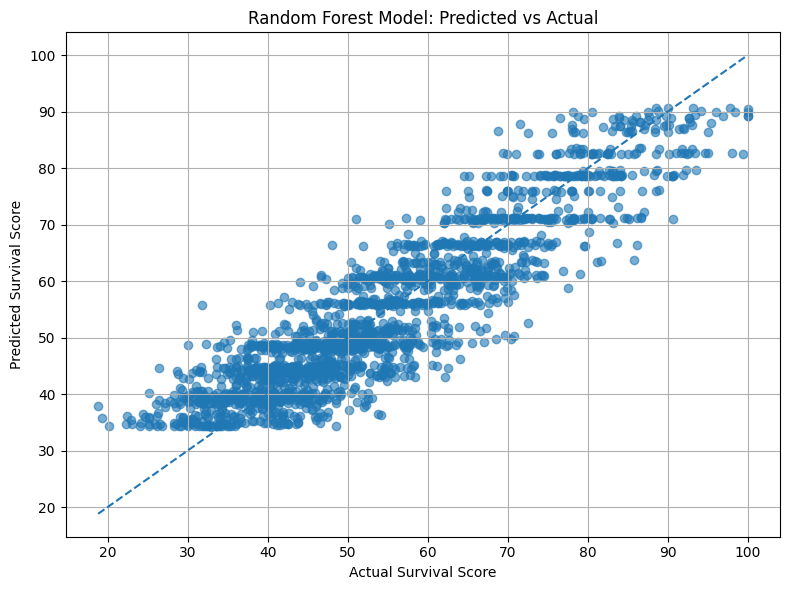

In [188]:
# ==============================
# 17) Predicted vs Actual Scatter Plot
# ==============================

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Survival Score")
plt.ylabel("Predicted Survival Score")
plt.title("Random Forest Model: Predicted vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

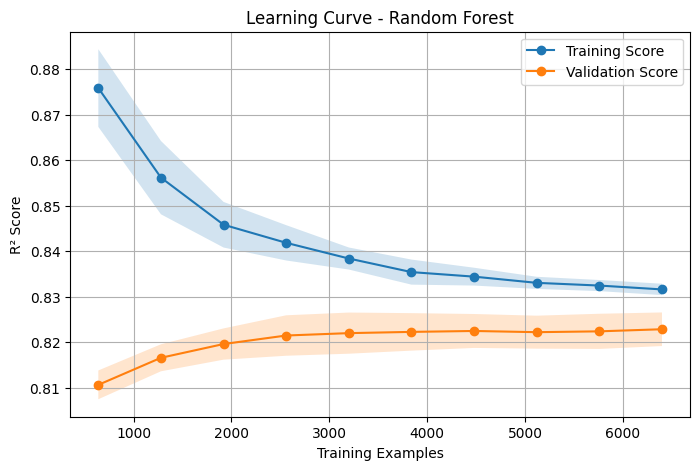

In [189]:
# random forest learning curve.

plot_learning_curve(
    model,
    X_train_processed,
    y_train,
    "Learning Curve - Random Forest"
)

In [190]:
# ==============================
# 18) Model Comparison
# ==============================

comparison_df = pd.DataFrame({
    "Model": ["Linear Regression","Decision Tree", "Random Forest"],
    "R² Score": [linear_r2, tree_r2,rf_r2],
    "MAE": [linear_mae, tree_mae,rf_mae],
    "RMSE": [linear_rmse, tree_rmse,rf_rmse]
})

print("\n==============================")
print("Model Comparison")
print("==============================")
print(comparison_df)


Model Comparison
               Model  R² Score       MAE      RMSE
0  Linear Regression  0.842812  4.978149  6.242558
1      Decision Tree  0.817782  5.341161  6.721228
2      Random Forest  0.820319  5.306425  6.674270


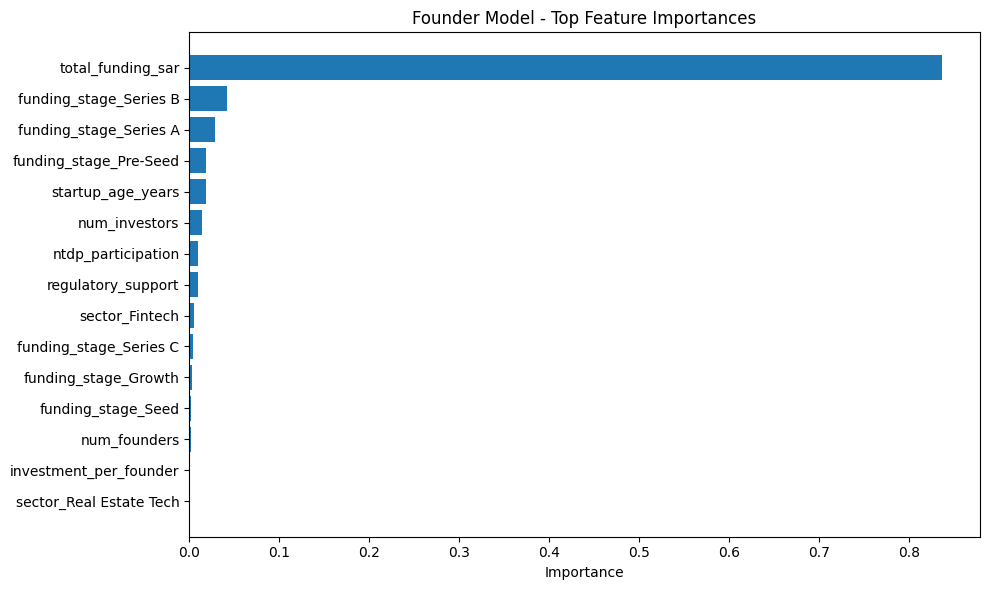


Top 15 Feature Importances:
                    Feature  Importance
1         total_funding_sar    0.836602
34   funding_stage_Series B    0.042147
33   funding_stage_Series A    0.029132
31   funding_stage_Pre-Seed    0.019061
0         startup_age_years    0.018561
3             num_investors    0.014539
8        ntdp_participation    0.009682
11       regulatory_support    0.009412
16           sector_Fintech    0.004916
35   funding_stage_Series C    0.004705
30     funding_stage_Growth    0.003392
32       funding_stage_Seed    0.002260
4              num_founders    0.001696
10   investment_per_founder    0.001245
20  sector_Real Estate Tech    0.001095


In [191]:
# ==============================
# 19) Feature Importance Plot
# ==============================

feature_names = (
    numerical_features
    + list(
        preprocessor
        .named_transformers_["cat"]
        .named_steps["encoder"]
        .get_feature_names_out(categorical_features)
    )
)

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Founder Model - Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nTop 15 Feature Importances:")
print(top_features)

In [192]:
# ==============================
# 20) Save Model and Preprocessor
# ==============================

joblib.dump(linear_model, "founder_model.joblib")
joblib.dump(preprocessor, "founder_preprocessor.joblib")

print("\n✅ Model saved → founder_model.joblib")
print("✅ Preprocessor saved → founder_preprocessor.joblib")


✅ Model saved → founder_model.joblib
✅ Preprocessor saved → founder_preprocessor.joblib


In [193]:

# ==============================
# 21) Results Interpretation Text
# ==============================

print("\n==============================")
print("Results Interpretation")
print("==============================")

print(f"""
The final Linear Regression model achieved an R² score of {linear_r2:.2f}.
This means the model explains approximately {linear_r2 * 100:.0f}% of the variation in the synthetic survival_score.

A high survival_score indicates stronger startup survival potential.
In this synthetic dataset, it is generally associated with stronger funding,
more investors, greater startup maturity, and participation in support programs.

A low survival_score suggests weaker startup performance across these factors
and may indicate the need for improvements in funding, investor attraction,
business maturity, or participation in support initiatives.

Among the evaluated models (Linear Regression, Decision Tree, and Random Forest),
Linear Regression achieved the highest R² score and the lowest prediction errors
(MAE and RMSE). It also showed excellent generalization, with nearly identical
training and validation performance, making it the most suitable model for this dataset.
""")


Results Interpretation

The final Linear Regression model achieved an R² score of 0.84.
This means the model explains approximately 84% of the variation in the synthetic survival_score.

A high survival_score indicates stronger startup survival potential.
In this synthetic dataset, it is generally associated with stronger funding,
more investors, greater startup maturity, and participation in support programs.

A low survival_score suggests weaker startup performance across these factors
and may indicate the need for improvements in funding, investor attraction,
business maturity, or participation in support initiatives.

Among the evaluated models (Linear Regression, Decision Tree, and Random Forest),
Linear Regression achieved the highest R² score and the lowest prediction errors
(MAE and RMSE). It also showed excellent generalization, with nearly identical
training and validation performance, making it the most suitable model for this dataset.



## Why Linear Regression Was Selected as the Final Model

Linear Regression was used as a baseline model because it is simple, efficient, and easy to interpret. To ensure a fair comparison, its performance was evaluated against Decision Tree and Random Forest using the same training and testing data.

Although Random Forest is capable of modeling complex non-linear relationships and feature interactions, it did not outperform Linear Regression on the Founder dataset. Linear Regression achieved the highest R² score and the lowest prediction errors (MAE and RMSE). In addition, its learning curve showed excellent generalization, with nearly identical training and validation performance, indicating that the model neither overfitted nor underfitted the data.

Therefore, Linear Regression was selected as the final model because it provided the best predictive performance and the most stable generalization among the evaluated models.

**Note**: The dataset used in this project is synthetic. Therefore, the reported performance reflects the model's ability to learn the relationships embedded in the simulated data rather than predicting real-world startup survival outcomes.

## Results Interpretation- Founder Model

The final Linear Regression model achieved an R² score of 0.84, meaning it explains approximately 84% of the variation in the synthetic survival_score.

Higher survival_score values indicate startups with stronger overall characteristics, such as higher funding, greater investor participation, stronger business maturity, and participation in support programs.

Lower survival_score values suggest that a startup may require improvements in these areas.

Since the dataset is synthetic, these results demonstrate how effectively the model learned the relationships embedded in the simulated data rather than predicting real-world startup outcomes.